In [38]:
import pandas as pd
import numpy as np

In [39]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("abbas829/telco-customer-churn-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'telco-customer-churn-dataset' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn-dataset


In [40]:
import os
os.listdir(path)

['Telco-Customer-Churn.csv']

In [41]:
df=pd.read_csv(path+'/Telco-Customer-Churn.csv')

In [42]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [44]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [45]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [46]:
df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [47]:
pd.crosstab(df["Churn"],df["Contract"])

Contract,Month-to-month,One year,Two year
Churn,,,
No,2220,1307,1647
Yes,1655,166,48


In [48]:
df["MonthlyCharges"].describe()

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [49]:
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


Target variable: Churn
Important input features : Contract,Tenure

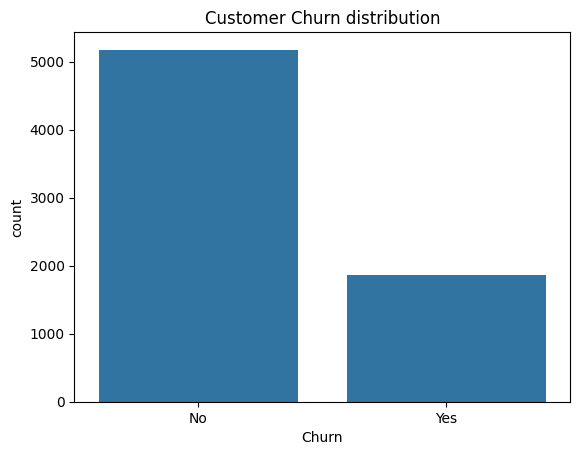

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn distribution")
plt.show()

In [56]:
df.drop("customerID",axis=1,inplace=True)

In [ ]:
df["TotalCharges"].unique()

In [52]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")


In [ ]:
print(df["TotalCharges"].dtype)

In [ ]:
df.isnull().sum()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

In [ ]:
df.select_dtypes(include="object").columns


In [ ]:
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [59]:
df["gender"]=df["gender"].map({"Male":1,"Female":0})

In [60]:
df=pd.get_dummies(df,drop_first=True)


In [61]:
df.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,0,1,29.85,29.85,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,1,0,34,56.95,1889.50,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,1,0,2,53.85,108.15,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,1,0,45,42.30,1840.75,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0,2,70.70,151.65,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [ ]:
df.info()

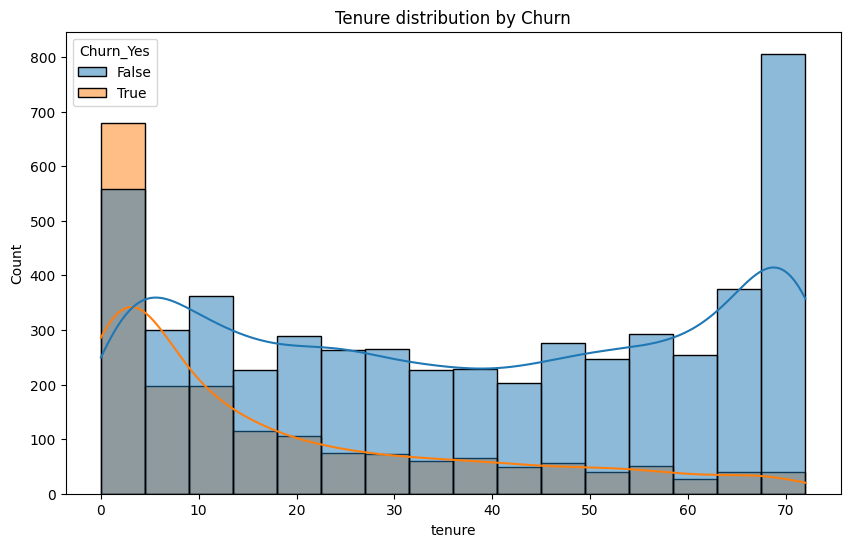

In [63]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn_Yes",
    kde=True
)
plt.title("Tenure distribution by Churn")
plt.show()

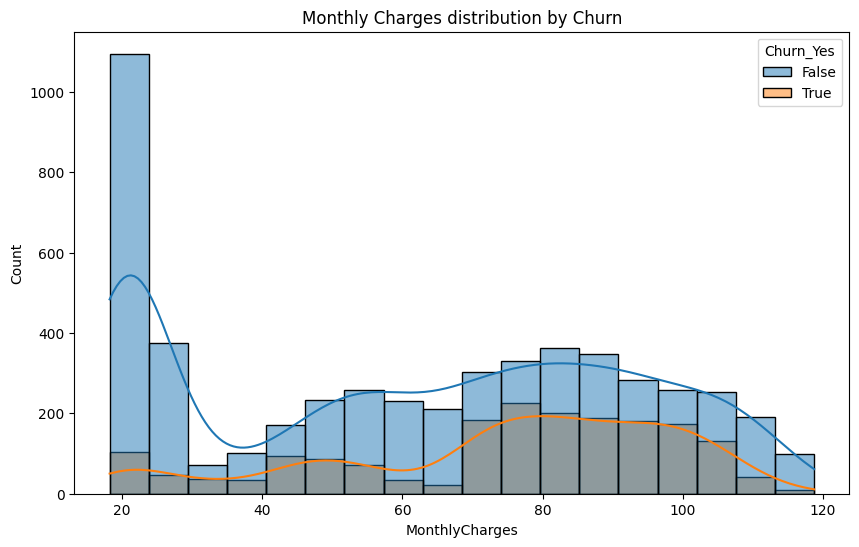

In [65]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn_Yes",
    kde=True
)
plt.title("Monthly Charges distribution by Churn")
plt.show()

In [ ]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

In [ ]:
columns_to_exclude = [col for col in df.columns if col.startswith('customerID_')]
df_filtered = df.drop(columns=columns_to_exclude)
sns.heatmap(df_filtered.corr())

In [69]:
corr=df.corr()
["Churn"].sort_values(ascending=False)
print(corr)

Churn_Yes                                1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender                                  -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


Customers who churn tend to have significantly shorter tenures.

Churning customers also tend to have higher monthly charges.

In [88]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())

In [89]:
X=df.drop("Churn_Yes",axis=1)
y=df["Churn_Yes"]

In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [93]:
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [94]:
y_pred=model.predict(X_test)

In [95]:
accuracy_score=accuracy_score(y_test,y_pred)
print(accuracy_score)

0.8218594748048261


In [96]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[934 102]
 [149 224]]


In [97]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409

